# 🧙 Harry Potter RAG Pipeline
### Retrieval-Augmented Generation over All 7 Harry Potter Books

---

## 📋 Project Overview

This notebook builds a complete end-to-end RAG system trained on the Harry Potter book series.

```
📄 Harry Potter PDFs (7 books)
        │
        ▼
  [1] PDF Loader          ← Extract raw text, tagged per book
        │
        ▼
  [2] Text Chunker        ← Split into overlapping chunks
        │
        ▼
  [3] Embedding Model     ← all-mpnet-base-v2 (768-dim)
        │
        ▼
  [4] ChromaDB Store      ← Persist vectors to disk
        │
        ▼
  [5] RAG Retriever       ← Query → retrieve top-k chunks
        │
        ▼
  [6] Cross-Encoder       ← Rerank candidates for precision
        │
        ▼
  [7] Groq LLM            ← Generate grounded answer
```

### ⚠️ Before You Run
1. Copy your 7 HP PDFs into the `pdf/` folder (see Step 2 for filenames)
2. Add your Groq API key to `.env` as `GROQ_API_KEY=your_key_here`
3. Run all cells top to bottom — first run takes ~10-15 min for embedding


---
## 🔧 Step 1 — Install Dependencies

In [1]:
import sys
!{sys.executable} -m pip install sentence-transformers chromadb pymupdf pypdf \
    groq python-dotenv tqdm numpy scikit-learn matplotlib ipywidgets --quiet
print("✅ All dependencies installed")

✅ All dependencies installed



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 📦 Step 2 — Imports & Configuration

In [2]:
import os, re, json, pickle, warnings, textwrap
from pathlib import Path
from typing import List, Dict, Any, Tuple, Optional
from dotenv import load_dotenv

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import fitz  # PyMuPDF
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.metrics.pairwise import cosine_similarity
import chromadb
from groq import Groq
from tqdm import tqdm

warnings.filterwarnings('ignore')
load_dotenv()  # loads GROQ_API_KEY from .env

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR    = Path(".").resolve()
PDF_DIR     = BASE_DIR / "pdf"
VECTOR_DIR  = BASE_DIR / "data" / "vector_store"
MODEL_DIR   = BASE_DIR / "models"
CHUNKS_FILE = BASE_DIR / "data" / "chunks.pkl"
META_FILE   = BASE_DIR / "data" / "metadata.json"

for d in [VECTOR_DIR, MODEL_DIR, BASE_DIR / "data", PDF_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Book metadata ─────────────────────────────────────────────────────────────
BOOK_NAMES = {
    1: "HP1: Sorcerer's Stone",
    2: "HP2: Chamber of Secrets",
    3: "HP3: Prisoner of Azkaban",
    4: "HP4: Goblet of Fire",
    5: "HP5: Order of the Phoenix",
    6: "HP6: Half-Blood Prince",
    7: "HP7: Deathly Hallows",
}

BOOK_PDF_PATHS = {
    1: PDF_DIR / "Harry_Potter_and_the_Sorcerers_Stone.pdf",
    2: PDF_DIR / "Harry_Potter_and_the_Chamber_of_Secrets.pdf",
    3: PDF_DIR / "Harry_Potter_and_the_Prisoner_of_Askaben.pdf",
    4: PDF_DIR / "Harry_Potter_and_the_Goblet_of_Fire.pdf",
    5: PDF_DIR / "Harry_Potter_and_the_Order_of_the_Phoenix.pdf",
    6: PDF_DIR / "Harry_Potter_and_the_Half_Blood_Prince.pdf",
    7: PDF_DIR / "Harry_Potter_and_the_Deathly_Hallows.pdf",
}

# ── LLM config ────────────────────────────────────────────────────────────────
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
if not GROQ_API_KEY:
    raise EnvironmentError("❌ GROQ_API_KEY not found. Add it to your .env file.")

GROQ_MODEL = "llama-3.3-70b-versatile"   # upgraded from 8b-instant

SYSTEM_PROMPT = """You are a knowledgeable Harry Potter expert assistant.
Answer questions using ONLY the provided book passages.
If the passages do not contain enough information, say so honestly.
Always cite which book and page the information comes from."""

# ── Colours (Hogwarts houses) ─────────────────────────────────────────────────
COLORS = {
    'gold': '#C9A84C', 'gryffindor': '#AE0001', 'slytherin': '#1A472A',
    'ravenclaw': '#0E1A40', 'hufflepuff': '#ECB939',
    'bg': '#0D0D0D', 'text': '#F5F5F5', 'highlight': '#E8D5B7',
}

print("✅ Configuration loaded")
print(f"   LLM      : {GROQ_MODEL}")
print(f"   Base dir : {BASE_DIR}")


✅ Configuration loaded
   LLM      : llama-3.3-70b-versatile
   Base dir : C:\Users\offic\OneDrive\Desktop\harry_potter_rag


---
## 📄 Step 3 — PDF Loader

Uses **PyMuPDF** for fast, accurate text extraction.  
Each page is tagged with its book number, name, and page number.

> **Subsequent runs:** If `chunks.pkl` already exists, loading is skipped automatically.


In [3]:
class HarryPotterPDFLoader:
    """Loads 7 individual HP PDFs using PyMuPDF. Each page is tagged with its book."""

    def __init__(self, pdf_paths: dict, max_pages_per_book: Optional[int] = None):
        self.pdf_paths          = pdf_paths
        self.max_pages_per_book = max_pages_per_book
        self.documents: List[Dict[str, Any]] = []
        self._stats: Dict[str, Any] = {}

    def _clean_text(self, text: str) -> str:
        text = re.sub(r'[ \t]+', ' ', text)
        text = re.sub(r'\n{3,}', '\n\n', text)
        return text.strip()

    def _load_book(self, book_num: int, pdf_path: Path) -> Tuple[List[Dict], int, int]:
        doc         = fitz.open(str(pdf_path))
        total_pages = len(doc)
        limit       = min(self.max_pages_per_book, total_pages) if self.max_pages_per_book else total_pages
        book_docs, skipped = [], 0

        for page_num in range(limit):
            raw = doc[page_num].get_text()
            if len(raw.strip()) < 30:
                skipped += 1
                continue
            text = self._clean_text(raw)
            book_docs.append({
                "page_content": text,
                "metadata": {
                    "source"    : pdf_path.name,
                    "page"      : page_num + 1,
                    "book_num"  : book_num,
                    "book_name" : BOOK_NAMES[book_num],
                    "char_count": len(text),
                },
            })
        doc.close()
        return book_docs, len(book_docs), skipped

    def load(self) -> List[Dict[str, Any]]:
        all_docs, book_counts, total_skipped = [], {}, 0
        for book_num in sorted(self.pdf_paths):
            pdf_path = self.pdf_paths[book_num]
            print(f"📖 Loading {BOOK_NAMES[book_num]} ({pdf_path.name})")
            book_docs, loaded, skipped = self._load_book(book_num, pdf_path)
            all_docs.extend(book_docs)
            book_counts[book_num] = loaded
            total_skipped += skipped
            print(f"   ✅ {loaded} pages loaded, {skipped} blank skipped")

        self.documents = all_docs
        self._stats = {"loaded_pages": len(all_docs), "skipped_pages": total_skipped, "book_counts": book_counts}
        print(f"\n✅ Total: {len(all_docs):,} pages loaded ({total_skipped} blank skipped)")
        return all_docs


In [4]:
# ── Load PDFs or restore from cache ──────────────────────────────────────────
if CHUNKS_FILE.exists():
    print("💾 chunks.pkl found — skipping PDF load (chunks will be loaded in Step 4)")
    documents = []
    loader    = None
else:
    # Verify all PDFs exist before starting
    missing = [f"HP{n}: {p.name}" for n, p in BOOK_PDF_PATHS.items() if not p.exists()]
    if missing:
        raise FileNotFoundError(f"Missing PDFs in pdf/ folder:\n" + "\n".join(missing))

    loader    = HarryPotterPDFLoader(BOOK_PDF_PATHS)
    documents = loader.load()


💾 chunks.pkl found — skipping PDF load (chunks will be loaded in Step 4)


---
## ✂️ Step 4 — Text Chunking

| Parameter | Value | Why |
|-----------|-------|-----|
| `chunk_size` | 1200 chars | Larger chunks keep more narrative context intact |
| `chunk_overlap` | 200 chars | Prevents passages being split at boundaries |
| `separators` | `\n\n → \n → . → ' '` | Respects paragraph/sentence structure |


In [5]:
class SmartTextChunker:
    """Recursively splits documents at natural language boundaries with overlap."""

    def __init__(self, chunk_size: int = 1200, chunk_overlap: int = 200):
        self.chunk_size    = chunk_size
        self.chunk_overlap = chunk_overlap
        self.separators    = ["\n\n", "\n", ". ", " ", ""]

    def _split_text(self, text: str) -> List[str]:
        if len(text) <= self.chunk_size:
            return [text] if text.strip() else []

        chunks = []
        for sep in self.separators:
            if sep and sep in text:
                parts, current = text.split(sep), ""
                for part in parts:
                    candidate = current + sep + part if current else part
                    if len(candidate) <= self.chunk_size:
                        current = candidate
                    else:
                        if current.strip():
                            chunks.append(current.strip())
                        current = text[-self.chunk_overlap:] + sep + part if chunks else part
                if current.strip():
                    chunks.append(current.strip())
                return chunks if chunks else [text[:self.chunk_size]]

        step = self.chunk_size - self.chunk_overlap
        return [text[i:i + self.chunk_size] for i in range(0, len(text), step)]

    def split_documents(self, documents: List[Dict]) -> List[Dict]:
        all_chunks = []
        for doc in tqdm(documents, desc="✂️  Chunking pages"):
            for i, chunk_text in enumerate(self._split_text(doc["page_content"])):
                if len(chunk_text.strip()) < 50:
                    continue
                all_chunks.append({
                    "page_content": chunk_text,
                    "metadata": {
                        **doc["metadata"],
                        "chunk_index" : i,
                        "chunk_length": len(chunk_text),
                        "chunk_id"    : f"p{doc['metadata']['page']}_c{i}",
                    },
                })
        return all_chunks


In [6]:
# ── Chunk or restore from cache ──────────────────────────────────────────────
if CHUNKS_FILE.exists():
    print("💾 Loading chunks from disk...")
    with open(CHUNKS_FILE, "rb") as f:
        chunks = pickle.load(f)
    print(f"✅ Loaded {len(chunks):,} chunks from chunks.pkl")
else:
    chunker = SmartTextChunker(chunk_size=1200, chunk_overlap=200)
    chunks  = chunker.split_documents(documents)
    with open(CHUNKS_FILE, "wb") as f:
        pickle.dump(chunks, f)
    print(f"\n✅ {len(chunks):,} chunks created and saved to disk")

lengths = [c['metadata']['chunk_length'] for c in chunks]
print(f"   Chunk size — min: {min(lengths)}  avg: {int(np.mean(lengths))}  max: {max(lengths)} chars")


💾 Loading chunks from disk...
✅ Loaded 7,079 chunks from chunks.pkl
   Chunk size — min: 55  avg: 983  max: 1200 chars


---
## 📊 Step 5 — Corpus Overview

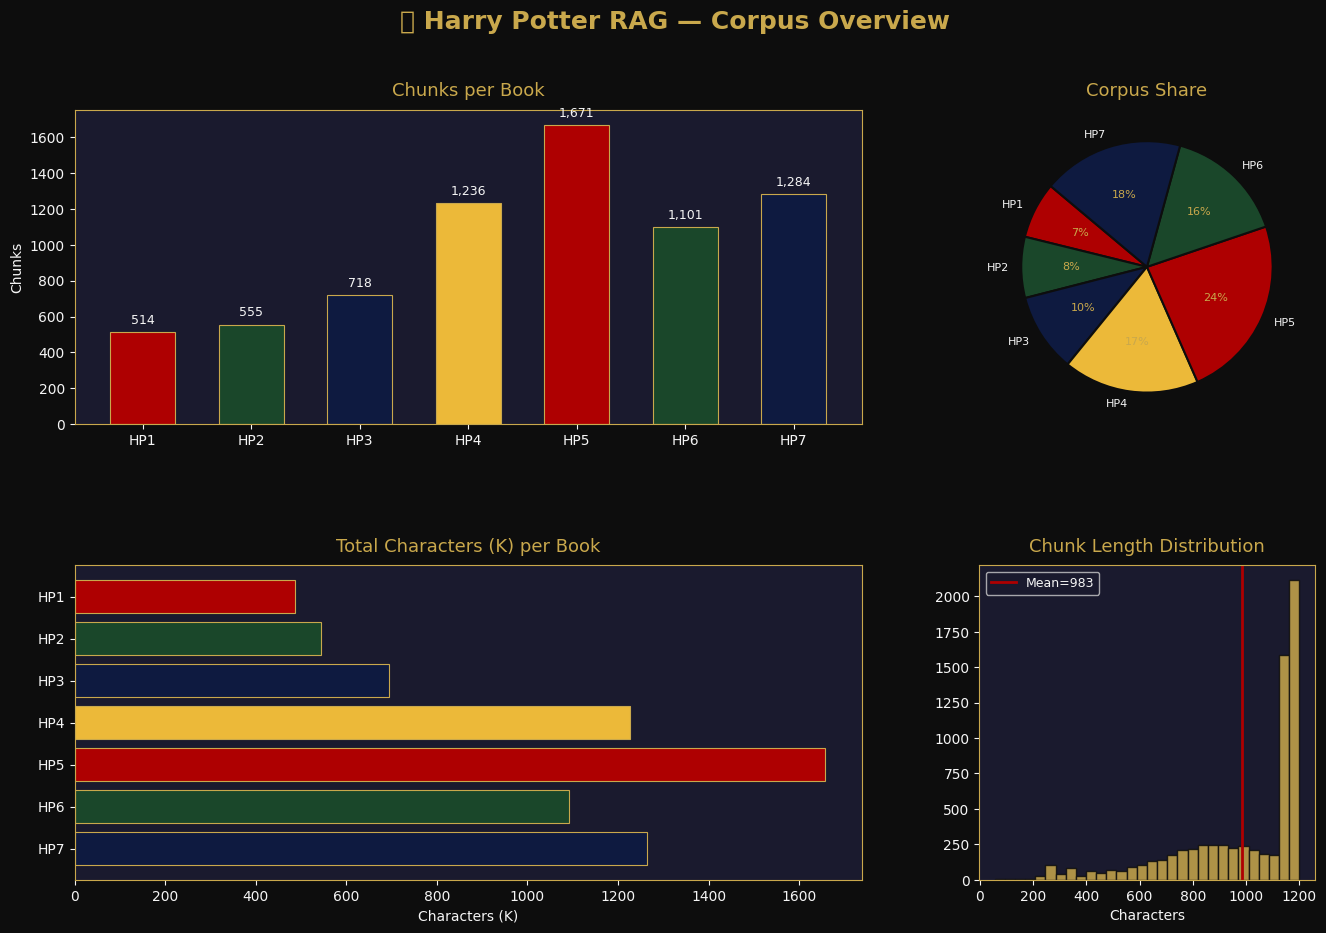

📊 Saved → data/corpus_overview.png


In [7]:
def plot_corpus_overview(chunks: List[Dict]):
    book_chunks = [sum(1 for c in chunks if c['metadata']['book_num'] == i) for i in range(1, 8)]
    book_chars  = [sum(c['metadata']['chunk_length'] for c in chunks if c['metadata']['book_num'] == i) / 1_000 for i in range(1, 8)]
    short_names = [f"HP{i}" for i in range(1, 8)]
    house_colors = [COLORS['gryffindor'], COLORS['slytherin'], COLORS['ravenclaw'],
                    COLORS['hufflepuff'], COLORS['gryffindor'], COLORS['slytherin'], COLORS['ravenclaw']]

    fig = plt.figure(figsize=(16, 10), facecolor=COLORS['bg'])
    fig.suptitle('🧙 Harry Potter RAG — Corpus Overview', fontsize=18, color=COLORS['gold'], fontweight='bold', y=0.98)
    gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    ax1 = fig.add_subplot(gs[0, :2]); ax1.set_facecolor('#1a1a2e')
    bars = ax1.bar(short_names, book_chunks, color=house_colors, edgecolor=COLORS['gold'], linewidth=0.8, width=0.6)
    for bar, val in zip(bars, book_chunks):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f'{val:,}',
                 ha='center', va='bottom', color=COLORS['text'], fontsize=9)
    ax1.set_title('Chunks per Book', color=COLORS['gold'], fontsize=13, pad=10)
    ax1.set_ylabel('Chunks', color=COLORS['text']); ax1.tick_params(colors=COLORS['text'])
    for sp in ax1.spines.values(): sp.set_edgecolor(COLORS['gold'])

    ax2 = fig.add_subplot(gs[0, 2]); ax2.set_facecolor('#1a1a2e')
    wedges, texts, autotexts = ax2.pie(book_chunks, labels=short_names, autopct='%1.0f%%',
        colors=house_colors, startangle=140,
        textprops={'color': COLORS['text'], 'fontsize': 8},
        wedgeprops={'edgecolor': COLORS['bg'], 'linewidth': 1.5})
    for at in autotexts: at.set_color(COLORS['gold'])
    ax2.set_title('Corpus Share', color=COLORS['gold'], fontsize=13, pad=10)

    ax3 = fig.add_subplot(gs[1, :2]); ax3.set_facecolor('#1a1a2e')
    ax3.barh(short_names[::-1], book_chars[::-1], color=house_colors[::-1], edgecolor=COLORS['gold'], linewidth=0.8)
    ax3.set_title('Total Characters (K) per Book', color=COLORS['gold'], fontsize=13, pad=10)
    ax3.set_xlabel('Characters (K)', color=COLORS['text']); ax3.tick_params(colors=COLORS['text'])
    for sp in ax3.spines.values(): sp.set_edgecolor(COLORS['gold'])

    ax4 = fig.add_subplot(gs[1, 2]); ax4.set_facecolor('#1a1a2e')
    lengths_all = [c['metadata']['chunk_length'] for c in chunks]
    ax4.hist(lengths_all, bins=30, color=COLORS['gold'], edgecolor=COLORS['bg'], alpha=0.85)
    ax4.axvline(np.mean(lengths_all), color=COLORS['gryffindor'], lw=2, label=f"Mean={int(np.mean(lengths_all))}")
    ax4.set_title('Chunk Length Distribution', color=COLORS['gold'], fontsize=13, pad=10)
    ax4.set_xlabel('Characters', color=COLORS['text']); ax4.tick_params(colors=COLORS['text'])
    ax4.legend(facecolor='#1a1a2e', labelcolor=COLORS['text'], fontsize=9)
    for sp in ax4.spines.values(): sp.set_edgecolor(COLORS['gold'])

    plt.savefig(BASE_DIR / 'data' / 'corpus_overview.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
    plt.show()
    print("📊 Saved → data/corpus_overview.png")

plot_corpus_overview(chunks)


---
## 🧠 Step 6 — Embedding Model

Upgraded to **`all-mpnet-base-v2`** — 768-dim vs 384-dim in v1, significantly better semantic recall.

| Property | Value |
|----------|-------|
| Model | `all-mpnet-base-v2` |
| Embedding dim | 768 |
| Size | ~420 MB |
| vs MiniLM | Much better on implicit/inferential queries |


In [8]:
class EmbeddingManager:
    """Wraps SentenceTransformer for batch embedding. Saves/loads from disk."""
    MODEL_NAME = "all-mpnet-base-v2"   # upgraded from all-MiniLM-L6-v2

    def __init__(self, model_dir: Path):
        self.model_dir  = model_dir
        self.model_path = model_dir / "embedding_model"
        self.model: Optional[SentenceTransformer] = None
        self.dim: int = 0

    def load_or_download(self):
        if self.model_path.exists():
            print(f"📂 Loading model from disk: {self.model_path}")
            self.model = SentenceTransformer(str(self.model_path))
        else:
            print(f"⬇️  Downloading {self.MODEL_NAME} (~420 MB)...")
            self.model = SentenceTransformer(self.MODEL_NAME)
            self.model.save(str(self.model_path))
            print(f"💾 Model saved → {self.model_path}")
        self.dim = self.model.get_sentence_embedding_dimension()
        print(f"✅ Model ready  (dim={self.dim})")
        return self

    def embed(self, texts: List[str], batch_size: int = 64, show_progress: bool = True) -> np.ndarray:
        if not self.model:
            raise RuntimeError("Call load_or_download() first.")
        all_embeddings = []
        for i in tqdm(range(0, len(texts), batch_size), desc="🧠 Embedding", disable=not show_progress):
            vecs = self.model.encode(texts[i:i+batch_size], convert_to_numpy=True,
                                     show_progress_bar=False, normalize_embeddings=True)
            all_embeddings.append(vecs)
        return np.vstack(all_embeddings)

embedding_manager = EmbeddingManager(MODEL_DIR).load_or_download()


📂 Loading model from disk: C:\Users\offic\OneDrive\Desktop\harry_potter_rag\models\embedding_model


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Model ready  (dim=768)


---
## 🗄️ Step 7 — ChromaDB Vector Store

Persistent HNSW index with deduplication. Re-indexing is skipped automatically if already done.

> ⚠️ If you switch embedding models, call `vector_store.clear()` before re-indexing.


In [9]:
class HarryPotterVectorStore:
    """Persistent ChromaDB store with deduplication and batch insertion."""
    COLLECTION = "harry_potter_rag"
    BATCH_SIZE  = 500

    def __init__(self, persist_dir: Path):
        self.persist_dir = persist_dir
        self.client      = chromadb.PersistentClient(path=str(persist_dir))
        self.collection  = self.client.get_or_create_collection(
            name=self.COLLECTION,
            metadata={"hnsw:space": "cosine"},
        )
        print(f"🗄️  Vector store ready — {self.collection.count():,} docs indexed")

    @property
    def doc_count(self) -> int:
        return self.collection.count()

    def clear(self):
        self.client.delete_collection(self.COLLECTION)
        self.collection = self.client.get_or_create_collection(
            name=self.COLLECTION, metadata={"hnsw:space": "cosine"})
        print("🗑️  Collection cleared.")

    def add_documents(self, chunks: List[Dict], embeddings: np.ndarray):
        existing = set()
        if self.doc_count > 0:
            existing = set(self.collection.get(include=[])['ids'])

        ids, docs, metas, embs = [], [], [], []
        for chunk, emb in zip(chunks, embeddings):
            cid = f"hp_{chunk['metadata']['chunk_id']}"
            if cid in existing:
                continue
            ids.append(cid)
            docs.append(chunk['page_content'])
            metas.append({k: str(v) for k, v in chunk['metadata'].items()})
            embs.append(emb.tolist())

        if not ids:
            print("⚠️  All chunks already indexed — skipping.")
            return

        print(f"➕ Inserting {len(ids):,} chunks...")
        for start in tqdm(range(0, len(ids), self.BATCH_SIZE), desc="💾 Storing"):
            end = start + self.BATCH_SIZE
            self.collection.add(ids=ids[start:end], documents=docs[start:end],
                                 metadatas=metas[start:end], embeddings=embs[start:end])
        print(f"✅ Done. Total indexed: {self.doc_count:,}")

    def query(self, query_embedding: np.ndarray, top_k: int = 40,
              book_filter: Optional[int] = None) -> List[Dict]:
        kwargs = dict(query_embeddings=[query_embedding.tolist()], n_results=top_k,
                      include=["documents", "metadatas", "distances"])
        if book_filter:
            kwargs["where"] = {"book_num": str(book_filter)}
        res = self.collection.query(**kwargs)
        return [{"text": doc, "metadata": meta, "score": round(1 - dist, 4)}
                for doc, meta, dist in zip(res['documents'][0], res['metadatas'][0], res['distances'][0])]


In [10]:
# ── Init store and embed if needed ───────────────────────────────────────────
vector_store = HarryPotterVectorStore(VECTOR_DIR)

if vector_store.doc_count == 0:
    if not chunks:
        raise RuntimeError("No chunks available. Run Steps 3-4 first.")
    print("\n🧠 Generating embeddings — this takes ~10-15 min on first run...")
    texts      = [c['page_content'] for c in chunks]
    embeddings = embedding_manager.embed(texts, batch_size=64)
    print(f"   Embedding matrix: {embeddings.shape}")
    vector_store.add_documents(chunks, embeddings)
    np.save(MODEL_DIR / "embeddings.npy", embeddings)
    print("💾 Embeddings saved → models/embeddings.npy")
else:
    print(f"✅ Already indexed — skipping embedding ({vector_store.doc_count:,} docs)")


🗄️  Vector store ready — 1,825 docs indexed
✅ Already indexed — skipping embedding (1,825 docs)


---
## 🔍 Step 8 — Retriever & Cross-Encoder Reranker

Two-stage retrieval:
1. **ChromaDB** — fast cosine similarity, retrieves top 40 candidates
2. **Cross-encoder** — precise pairwise scoring, selects best 5

This catches answers the embedding model would otherwise miss.


In [11]:
# ── Cross-encoder (reranker) ──────────────────────────────────────────────────
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', max_length=512)
print("✅ Cross-encoder loaded")

groq_client = Groq(api_key=GROQ_API_KEY)
print(f"✅ Groq client ready  (model: {GROQ_MODEL})")


def retrieve_chunks(query: str, top_k: int = 40,
                    book_filter: Optional[int] = None) -> List[Dict]:
    """Embed query and retrieve top_k candidates from ChromaDB."""
    query_vec = embedding_manager.embed([query], show_progress=False)[0]
    return vector_store.query(query_vec, top_k=top_k, book_filter=book_filter)


def rerank_chunks(query: str, candidates: List[Dict], top_k: int = 5) -> List[Dict]:
    """Score each candidate with the cross-encoder, return top_k."""
    scores = cross_encoder.predict([(query, c['text']) for c in candidates])
    for c, s in zip(candidates, scores):
        c['rerank_score'] = float(s)
    return sorted(candidates, key=lambda x: x['rerank_score'], reverse=True)[:top_k]


def build_context(chunks_list: List[Dict]) -> str:
    return "\n\n".join(
        f"[Passage {i} — {c['metadata'].get('book_name','?')}, Page {c['metadata'].get('page','?')}]\n{c['text']}"
        for i, c in enumerate(chunks_list, 1)
    )


def ask(question: str, retrieve_k: int = 40, final_k: int = 5,
        book: Optional[int] = None) -> Dict:
    """
    Main entry point. Ask any question about Harry Potter.

    Args:
        question   : Natural language question
        retrieve_k : Candidates to retrieve from ChromaDB (default 40)
        final_k    : Passages to send to LLM after reranking (default 5)
        book       : Restrict to a specific book 1-7 (None = all)

    Returns:
        dict with 'answer' and 'sources'

    Examples:
        ask("Who gave Harry the invisibility cloak?")
        ask("Who is the Half-Blood Prince?", book=6)
    """
    candidates = retrieve_chunks(question, top_k=retrieve_k, book_filter=book)
    reranked   = rerank_chunks(question, candidates, top_k=final_k)
    context    = build_context(reranked)

    response = groq_client.chat.completions.create(
        model       = GROQ_MODEL,
        messages    = [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': f'Book passages:\n{context}\n\nQuestion: {question}'},
        ],
        max_tokens  = 1024,
        temperature = 0.2,
    )

    return {
        'answer' : response.choices[0].message.content,
        'sources': [
            {
                'book'        : c['metadata'].get('book_name', '?'),
                'page'        : c['metadata'].get('page', '?'),
                'rerank_score': round(c['rerank_score'], 4),
            }
            for c in reranked
        ],
    }

print("✅ ask() ready")


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

✅ Cross-encoder loaded
✅ Groq client ready  (model: llama-3.3-70b-versatile)
✅ ask() ready


---
## 🖨️ Step 9 — Display Helper

In [12]:
from IPython.display import display, Markdown

def show(question: str, retrieve_k: int = 40, final_k: int = 5,
         book: Optional[int] = None):
    """Pretty-print an ask() result with sources."""
    print(f"\n{'═'*65}")
    print(f"  🔍 {question}")
    if book:
        print(f"  📘 Filtered to: {BOOK_NAMES[book]}")
    print(f"{'─'*65}")

    result = ask(question, retrieve_k=retrieve_k, final_k=final_k, book=book)

    display(Markdown(result['answer']))
    print("\n📚 Sources:")
    for s in result['sources']:
        print(f"  {s['book']}, p.{s['page']}  (rerank score: {s['rerank_score']})")
    print()
    return result

print("✅ show() ready")


✅ show() ready


---
## 🧪 Step 10 — Example Queries

These demonstrate the full pipeline. Edit the questions or add your own.


In [13]:
show("Who gave Harry the invisibility cloak and why?")


═════════════════════════════════════════════════════════════════
  🔍 Who gave Harry the invisibility cloak and why?
─────────────────────────────────────────────────────────────────


According to Passage 2 (HP1: Sorcerer's Stone, Page 259), the Invisibility Cloak was given to Harry by Professor Dumbledore. Dumbledore stated that Harry's father had left the cloak in his possession, and he thought Harry might like it. Dumbledore mentioned that Harry's father used the cloak mainly for sneaking off to the kitchens to steal food when he was at Hogwarts. 

Additionally, Passage 4 (HP1: Sorcerer's Stone, Page 226) provides more information about the cloak being given to Harry. It was found folded neatly underneath Harry's sheets with a note pinned to it that said "Just in case." However, it does not explicitly state who gave it to him, but based on Passage 2, we can infer that it was Dumbledore who gave the cloak to Harry.


📚 Sources:
  HP3: Prisoner of Azkaban, p.364  (rerank score: 5.7325)
  HP1: Sorcerer's Stone, p.259  (rerank score: 5.2201)
  HP4: Goblet of Fire, p.398  (rerank score: 3.7861)
  HP1: Sorcerer's Stone, p.226  (rerank score: 3.6833)
  HP1: Sorcerer's Stone, p.178  (rerank score: 3.5693)



{'answer': 'According to Passage 2 (HP1: Sorcerer\'s Stone, Page 259), the Invisibility Cloak was given to Harry by Professor Dumbledore. Dumbledore stated that Harry\'s father had left the cloak in his possession, and he thought Harry might like it. Dumbledore mentioned that Harry\'s father used the cloak mainly for sneaking off to the kitchens to steal food when he was at Hogwarts. \n\nAdditionally, Passage 4 (HP1: Sorcerer\'s Stone, Page 226) provides more information about the cloak being given to Harry. It was found folded neatly underneath Harry\'s sheets with a note pinned to it that said "Just in case." However, it does not explicitly state who gave it to him, but based on Passage 2, we can infer that it was Dumbledore who gave the cloak to Harry.',
 'sources': [{'book': 'HP3: Prisoner of Azkaban',
   'page': '364',
   'rerank_score': 5.7325},
  {'book': "HP1: Sorcerer's Stone", 'page': '259', 'rerank_score': 5.2201},
  {'book': 'HP4: Goblet of Fire', 'page': '398', 'rerank_sco

In [14]:
show("What are Horcruxes and how did Voldemort create them?")


═════════════════════════════════════════════════════════════════
  🔍 What are Horcruxes and how did Voldemort create them?
─────────────────────────────────────────────────────────────────


The provided passages do not contain enough information to fully explain what Horcruxes are and how Voldemort created them. However, Passage 5 from HP6: Half-Blood Prince, Page 432, mentions that it is possible to use animals as Horcruxes, but it is inadvisable because the object can think and move for itself. 

Additionally, Passage 1 from HP4: Goblet of Fire, Page 562, describes a scene where a "dense, smoky hand" and the "torso of Cedric Diggory" emerge from Voldemort's wand, suggesting that Voldemort's wand may be connected to the souls of his victims, but it does not explicitly explain the concept of Horcruxes or how they were created.

More information from other passages or books would be needed to provide a complete answer to this question.


📚 Sources:
  HP4: Goblet of Fire, p.562  (rerank score: -1.4459)
  HP5: Order of the Phoenix, p.790  (rerank score: -2.1199)
  HP4: Goblet of Fire, p.560  (rerank score: -2.3683)
  HP4: Goblet of Fire, p.552  (rerank score: -3.2064)
  HP6: Half-Blood Prince, p.432  (rerank score: -3.2296)



{'answer': 'The provided passages do not contain enough information to fully explain what Horcruxes are and how Voldemort created them. However, Passage 5 from HP6: Half-Blood Prince, Page 432, mentions that it is possible to use animals as Horcruxes, but it is inadvisable because the object can think and move for itself. \n\nAdditionally, Passage 1 from HP4: Goblet of Fire, Page 562, describes a scene where a "dense, smoky hand" and the "torso of Cedric Diggory" emerge from Voldemort\'s wand, suggesting that Voldemort\'s wand may be connected to the souls of his victims, but it does not explicitly explain the concept of Horcruxes or how they were created.\n\nMore information from other passages or books would be needed to provide a complete answer to this question.',
 'sources': [{'book': 'HP4: Goblet of Fire',
   'page': '562',
   'rerank_score': -1.4459},
  {'book': 'HP5: Order of the Phoenix',
   'page': '790',
   'rerank_score': -2.1199},
  {'book': 'HP4: Goblet of Fire', 'page': 

In [15]:
show("What happened to Dumbledore at the end?", book=6)


═════════════════════════════════════════════════════════════════
  🔍 What happened to Dumbledore at the end?
  📘 Filtered to: HP6: Half-Blood Prince
─────────────────────────────────────────────────────────────────


According to the provided passages, it can be inferred that Dumbledore passed away. This is mentioned in Passage 1 (HP6: Half-Blood Prince, Page 548) where it says "the feeling that they, at least, were sorry for Dumbledore's passing" and in Passage 2 (HP6: Half-Blood Prince, Page 521) where it says "the enormous and incomprehensible truth: that never again would Dumbledore speak to him, never again could he help". However, the exact circumstances of his death are not mentioned in the provided passages.


📚 Sources:
  HP6: Half-Blood Prince, p.548  (rerank score: 2.6235)
  HP6: Half-Blood Prince, p.521  (rerank score: 2.0222)
  HP6: Half-Blood Prince, p.44  (rerank score: -0.5646)
  HP6: Half-Blood Prince, p.549  (rerank score: -1.2732)
  HP6: Half-Blood Prince, p.436  (rerank score: -2.2124)



{'answer': 'According to the provided passages, it can be inferred that Dumbledore passed away. This is mentioned in Passage 1 (HP6: Half-Blood Prince, Page 548) where it says "the feeling that they, at least, were sorry for Dumbledore\'s passing" and in Passage 2 (HP6: Half-Blood Prince, Page 521) where it says "the enormous and incomprehensible truth: that never again would Dumbledore speak to him, never again could he help". However, the exact circumstances of his death are not mentioned in the provided passages.',
 'sources': [{'book': 'HP6: Half-Blood Prince',
   'page': '548',
   'rerank_score': 2.6235},
  {'book': 'HP6: Half-Blood Prince', 'page': '521', 'rerank_score': 2.0222},
  {'book': 'HP6: Half-Blood Prince', 'page': '44', 'rerank_score': -0.5646},
  {'book': 'HP6: Half-Blood Prince', 'page': '549', 'rerank_score': -1.2732},
  {'book': 'HP6: Half-Blood Prince', 'page': '436', 'rerank_score': -2.2124}]}

In [16]:
show("How does the Sorting Hat decide which house a student belongs to?")


═════════════════════════════════════════════════════════════════
  🔍 How does the Sorting Hat decide which house a student belongs to?
─────────────────────────────────────────────────────────────────


The provided book passages do not explicitly explain how the Sorting Hat decides which house a student belongs to. Passage 1 (HP1: Sorcerer's Stone, Page 104) only mentions that the Sorting Hat can "see" what's in a student's head and will tell them where they ought to be, but it doesn't reveal the specific criteria or process used to make this decision. 

Therefore, based on the provided passages, it's not possible to determine exactly how the Sorting Hat decides which house a student belongs to. (HP1: Sorcerer's Stone, Page 104)


📚 Sources:
  HP1: Sorcerer's Stone, p.104  (rerank score: 1.1983)
  HP1: Sorcerer's Stone, p.100  (rerank score: -0.8432)
  HP4: Goblet of Fire, p.494  (rerank score: -1.7501)
  HP1: Sorcerer's Stone, p.189  (rerank score: -2.4528)
  HP1: Sorcerer's Stone, p.101  (rerank score: -3.3368)



{'answer': 'The provided book passages do not explicitly explain how the Sorting Hat decides which house a student belongs to. Passage 1 (HP1: Sorcerer\'s Stone, Page 104) only mentions that the Sorting Hat can "see" what\'s in a student\'s head and will tell them where they ought to be, but it doesn\'t reveal the specific criteria or process used to make this decision. \n\nTherefore, based on the provided passages, it\'s not possible to determine exactly how the Sorting Hat decides which house a student belongs to. (HP1: Sorcerer\'s Stone, Page 104)',
 'sources': [{'book': "HP1: Sorcerer's Stone",
   'page': '104',
   'rerank_score': 1.1983},
  {'book': "HP1: Sorcerer's Stone", 'page': '100', 'rerank_score': -0.8432},
  {'book': 'HP4: Goblet of Fire', 'page': '494', 'rerank_score': -1.7501},
  {'book': "HP1: Sorcerer's Stone", 'page': '189', 'rerank_score': -2.4528},
  {'book': "HP1: Sorcerer's Stone", 'page': '101', 'rerank_score': -3.3368}]}

---
## 💾 Step 11 — Save Pipeline Metadata

In [17]:
meta = {
    "project"         : "Harry Potter RAG Pipeline",
    "pdf_files"       : [p.name for p in BOOK_PDF_PATHS.values()],
    "total_chunks"    : len(chunks),
    "chunk_size"      : 1200,
    "chunk_overlap"   : 200,
    "embedding_model" : EmbeddingManager.MODEL_NAME,
    "embedding_dim"   : embedding_manager.dim,
    "vector_store"    : "ChromaDB (persistent HNSW)",
    "collection_name" : HarryPotterVectorStore.COLLECTION,
    "docs_indexed"    : vector_store.doc_count,
    "groq_model"      : GROQ_MODEL,
    "books_included"  : list(BOOK_NAMES.values()),
}

with open(META_FILE, 'w') as f:
    json.dump(meta, f, indent=2)

print("💾 Metadata saved → data/metadata.json")
for k, v in meta.items():
    print(f"   {k:<22}: {v}")


💾 Metadata saved → data/metadata.json
   project               : Harry Potter RAG Pipeline
   pdf_files             : ['Harry_Potter_and_the_Sorcerers_Stone.pdf', 'Harry_Potter_and_the_Chamber_of_Secrets.pdf', 'Harry_Potter_and_the_Prisoner_of_Askaben.pdf', 'Harry_Potter_and_the_Goblet_of_Fire.pdf', 'Harry_Potter_and_the_Order_of_the_Phoenix.pdf', 'Harry_Potter_and_the_Half_Blood_Prince.pdf', 'Harry_Potter_and_the_Deathly_Hallows.pdf']
   total_chunks          : 7079
   chunk_size            : 1200
   chunk_overlap         : 200
   embedding_model       : all-mpnet-base-v2
   embedding_dim         : 768
   vector_store          : ChromaDB (persistent HNSW)
   collection_name       : harry_potter_rag
   docs_indexed          : 1825
   groq_model            : llama-3.3-70b-versatile
   books_included        : ["HP1: Sorcerer's Stone", 'HP2: Chamber of Secrets', 'HP3: Prisoner of Azkaban', 'HP4: Goblet of Fire', 'HP5: Order of the Phoenix', 'HP6: Half-Blood Prince', 'HP7: Deathly Hallows'

---
## ✏️ Step 12 — Ask Your Own Questions

Use `show()` with any question. Optionally filter by book number.


In [18]:
# ── Edit these and run ────────────────────────────────────────────────────────
show("What is the prophecy about Harry and Voldemort?")



═════════════════════════════════════════════════════════════════
  🔍 What is the prophecy about Harry and Voldemort?
─────────────────────────────────────────────────────────────────


According to Passage 2 (HP5: Order of the Phoenix, Page 816) and Passage 3 (HP5: Order of the Phoenix, Page 817), the prophecy is about a boy who can vanquish Voldemort. The prophecy states that Voldemort would "mark him as his equal," which he did by giving Harry a scar. The prophecy also refers to a boy born at the end of July, which applies to both Harry and Neville Longbottom. However, Dumbledore explains that Voldemort chose Harry, not Neville, and marked him with the scar, giving him powers and a future that have allowed him to escape Voldemort multiple times.

Unfortunately, the exact wording of the prophecy is not provided in the given passages. However, it is mentioned in Passage 3 (HP5: Order of the Phoenix, Page 817) that the prophecy has a "final identifying feature of the boy who could vanquish Voldemort," which is that Voldemort would mark him as his equal.


📚 Sources:
  HP5: Order of the Phoenix, p.787  (rerank score: 6.4712)
  HP5: Order of the Phoenix, p.816  (rerank score: 6.0322)
  HP5: Order of the Phoenix, p.817  (rerank score: 5.1775)
  HP5: Order of the Phoenix, p.761  (rerank score: 4.9244)
  HP5: Order of the Phoenix, p.804  (rerank score: 4.3195)



{'answer': 'According to Passage 2 (HP5: Order of the Phoenix, Page 816) and Passage 3 (HP5: Order of the Phoenix, Page 817), the prophecy is about a boy who can vanquish Voldemort. The prophecy states that Voldemort would "mark him as his equal," which he did by giving Harry a scar. The prophecy also refers to a boy born at the end of July, which applies to both Harry and Neville Longbottom. However, Dumbledore explains that Voldemort chose Harry, not Neville, and marked him with the scar, giving him powers and a future that have allowed him to escape Voldemort multiple times.\n\nUnfortunately, the exact wording of the prophecy is not provided in the given passages. However, it is mentioned in Passage 3 (HP5: Order of the Phoenix, Page 817) that the prophecy has a "final identifying feature of the boy who could vanquish Voldemort," which is that Voldemort would mark him as his equal.',
 'sources': [{'book': 'HP5: Order of the Phoenix',
   'page': '787',
   'rerank_score': 6.4712},
  {

In [19]:
show("Who is the Half-Blood Prince and what is his connection to Snape?", book=6)



═════════════════════════════════════════════════════════════════
  🔍 Who is the Half-Blood Prince and what is his connection to Snape?
  📘 Filtered to: HP6: Half-Blood Prince
─────────────────────────────────────────────────────────────────


The provided book passages do not contain enough information to determine who the Half-Blood Prince is and his connection to Snape. The passages provided are snippets of conversations and events, but they do not explicitly mention the Half-Blood Prince or his relationship with Snape. To answer this question, more information from the book "Harry Potter and the Half-Blood Prince" would be needed.


📚 Sources:
  HP6: Half-Blood Prince, p.33  (rerank score: -5.9451)
  HP6: Half-Blood Prince, p.548  (rerank score: -11.1861)
  HP6: Half-Blood Prince, p.328  (rerank score: -11.2193)
  HP6: Half-Blood Prince, p.514  (rerank score: -11.2256)
  HP6: Half-Blood Prince, p.546  (rerank score: -11.2471)



{'answer': 'The provided book passages do not contain enough information to determine who the Half-Blood Prince is and his connection to Snape. The passages provided are snippets of conversations and events, but they do not explicitly mention the Half-Blood Prince or his relationship with Snape. To answer this question, more information from the book "Harry Potter and the Half-Blood Prince" would be needed.',
 'sources': [{'book': 'HP6: Half-Blood Prince',
   'page': '33',
   'rerank_score': -5.9451},
  {'book': 'HP6: Half-Blood Prince', 'page': '548', 'rerank_score': -11.1861},
  {'book': 'HP6: Half-Blood Prince', 'page': '328', 'rerank_score': -11.2193},
  {'book': 'HP6: Half-Blood Prince', 'page': '514', 'rerank_score': -11.2256},
  {'book': 'HP6: Half-Blood Prince', 'page': '546', 'rerank_score': -11.2471}]}

In [20]:
show("Describe the first Quidditch match Harry ever played in")



═════════════════════════════════════════════════════════════════
  🔍 Describe the first Quidditch match Harry ever played in
─────────────────────────────────────────────────────────────────


The provided book passages do not contain a detailed description of the first Quidditch match Harry ever played in. However, from Passage 2 (HP1: Sorcerer's Stone, Page 157), we know that Harry's first Quidditch match was against Slytherin, and if Gryffindor won, they would move up into second place in the House Championship. 

Additionally, Passage 1 (HP1: Sorcerer's Stone, Page 158) mentions that the day before Harry's first Quidditch match, he, Ron, and Hermione were out in the freezing courtyard during break, and Hermione had conjured up a bright blue fire to keep them warm. However, it does not provide information about the match itself.

To describe the first Quidditch match Harry played in, more information from the book is needed, which is not provided in the given passages.


📚 Sources:
  HP1: Sorcerer's Stone, p.158  (rerank score: 6.4535)
  HP1: Sorcerer's Stone, p.157  (rerank score: 6.1508)
  HP2: Chamber of Secrets, p.142  (rerank score: 4.1909)
  HP4: Goblet of Fire, p.465  (rerank score: 3.3027)
  HP1: Sorcerer's Stone, p.133  (rerank score: 3.2279)



{'answer': "The provided book passages do not contain a detailed description of the first Quidditch match Harry ever played in. However, from Passage 2 (HP1: Sorcerer's Stone, Page 157), we know that Harry's first Quidditch match was against Slytherin, and if Gryffindor won, they would move up into second place in the House Championship. \n\nAdditionally, Passage 1 (HP1: Sorcerer's Stone, Page 158) mentions that the day before Harry's first Quidditch match, he, Ron, and Hermione were out in the freezing courtyard during break, and Hermione had conjured up a bright blue fire to keep them warm. However, it does not provide information about the match itself.\n\nTo describe the first Quidditch match Harry played in, more information from the book is needed, which is not provided in the given passages.",
 'sources': [{'book': "HP1: Sorcerer's Stone",
   'page': '158',
   'rerank_score': 6.4535},
  {'book': "HP1: Sorcerer's Stone", 'page': '157', 'rerank_score': 6.1508},
  {'book': 'HP2: Ch

---
## ✅ Summary

| Component | Details |
|-----------|---------|
| **PDFs** | 7 individual Harry Potter books |
| **Loader** | PyMuPDF with per-book metadata |
| **Chunker** | 1200 chars / 200 overlap (up from 800/150) |
| **Embedding** | `all-mpnet-base-v2` 768-dim (up from MiniLM 384-dim) |
| **Vector Store** | ChromaDB persistent HNSW index |
| **Retrieval** | Top-40 candidates → cross-encoder reranked to top-5 |
| **LLM** | `llama-3.3-70b-versatile` via Groq (up from 8b-instant) |
| **API key** | Loaded from `.env` — never hardcoded |
| **Kernel restarts** | Handled — chunks/embeddings loaded from disk automatically |
